# 🛒 Retail Sales Forecasting — Walmart Dataset
### End-to-End Machine Learning Pipeline

> **Portfolio Project** | Predicting weekly department-level sales across 45 Walmart stores using XGBoost with advanced feature engineering, WMAE-weighted evaluation, and multi-model comparison.

---

| | |
|---|---|
| **Dataset** | Walmart Store Sales (Kaggle) |
| **Rows** | 421,570 training records |
| **Stores** | 45 stores, 3 types (A / B / C) |
| **Departments** | 81 departments |
| **Target** | `Weekly_Sales` (USD) |
| **Key Metric** | Weighted MAE (holiday weeks × 5) |

---

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Overview](#2-data-loading--overview)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Data Cleaning](#4-data-cleaning)
5. [Feature Engineering](#5-feature-engineering)
6. [Model Training — Baseline to Advanced](#6-model-training)
7. [Evaluation & Model Comparison](#7-evaluation--model-comparison)
8. [Feature Importance & SHAP](#8-feature-importance--shap)
9. [Store & Department Deep-Dive](#9-store--department-deep-dive)
10. [Test Predictions & Submission](#10-test-predictions--submission)
11. [Conclusions & Next Steps](#11-conclusions--next-steps)


## 1. Environment Setup

In [1]:
# Install optional packages
# pip install xgboost lightgbm shap --quiet

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print("LightGBM not installed — skipping LGB model.")

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed — skipping SHAP analysis.")

# ── Plotting defaults ──
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = sns.color_palette("husl", 10)
print("Libraries loaded successfully")


Libraries loaded successfully


## 2. Data Loading & Overview

### Dataset Description
| File | Description |
|------|-------------|
| `train.csv` | Weekly sales per store-dept pair (2010-02 → 2012-10) |
| `test.csv` | Store-dept pairs to predict |
| `features.csv` | External features: temperature, fuel, markdowns, CPI, unemployment |
| `stores.csv` | Store type (A/B/C) and size |


In [3]:
train    = pd.read_csv(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\data\raw\train.csv')
test     = pd.read_csv(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\data\raw\test.csv')
features = pd.read_csv(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\data\raw\features.csv')
stores   = pd.read_csv(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\data\raw\stores.csv')

# Parse dates
for df in [train, test, features]:
    df['Date'] = pd.to_datetime(df['Date'])

print(f"Train:    {train.shape[0]:>7,} rows × {train.shape[1]} cols")
print(f"Test:     {test.shape[0]:>7,} rows × {test.shape[1]} cols")
print(f"Features: {features.shape[0]:>7,} rows × {features.shape[1]} cols")
print(f"Stores:   {stores.shape[0]:>7,} rows × {stores.shape[1]} cols")
print(f"\nDate range: {train['Date'].min().date()} → {train['Date'].max().date()}")
print(f"Stores: {train['Store'].nunique()}  |  Depts: {train['Dept'].nunique()}")


Train:    421,570 rows × 5 cols
Test:     115,064 rows × 4 cols
Features:   8,190 rows × 12 cols
Stores:        45 rows × 3 cols

Date range: 2010-02-05 → 2012-10-26
Stores: 45  |  Depts: 81


In [4]:
train.head(3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False


In [5]:
features.head(3)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False


In [6]:
stores.head(3)


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392


In [7]:
# Quick stats
print("=== TRAIN SUMMARY ===")
print(train.describe().round(2))
print(f"\nNegative sales rows: {(train['Weekly_Sales'] < 0).sum():,}")
print(f"Holiday weeks: {train['IsHoliday'].sum():,} / {len(train):,} ({train['IsHoliday'].mean()*100:.1f}%)")


=== TRAIN SUMMARY ===
           Store       Dept                           Date  Weekly_Sales
count  421570.00  421570.00                         421570     421570.00
mean       22.20      44.26  2011-06-18 08:30:31.963375104      15981.26
min         1.00       1.00            2010-02-05 00:00:00      -4988.94
25%        11.00      18.00            2010-10-08 00:00:00       2079.65
50%        22.00      37.00            2011-06-17 00:00:00       7612.03
75%        33.00      74.00            2012-02-24 00:00:00      20205.85
max        45.00      99.00            2012-10-26 00:00:00     693099.36
std        12.79      30.49                            NaN      22711.18

Negative sales rows: 1,285
Holiday weeks: 29,661 / 421,570 (7.0%)


## 3. Exploratory Data Analysis

We explore sales patterns across time, stores, departments, and holiday effects before building any model.


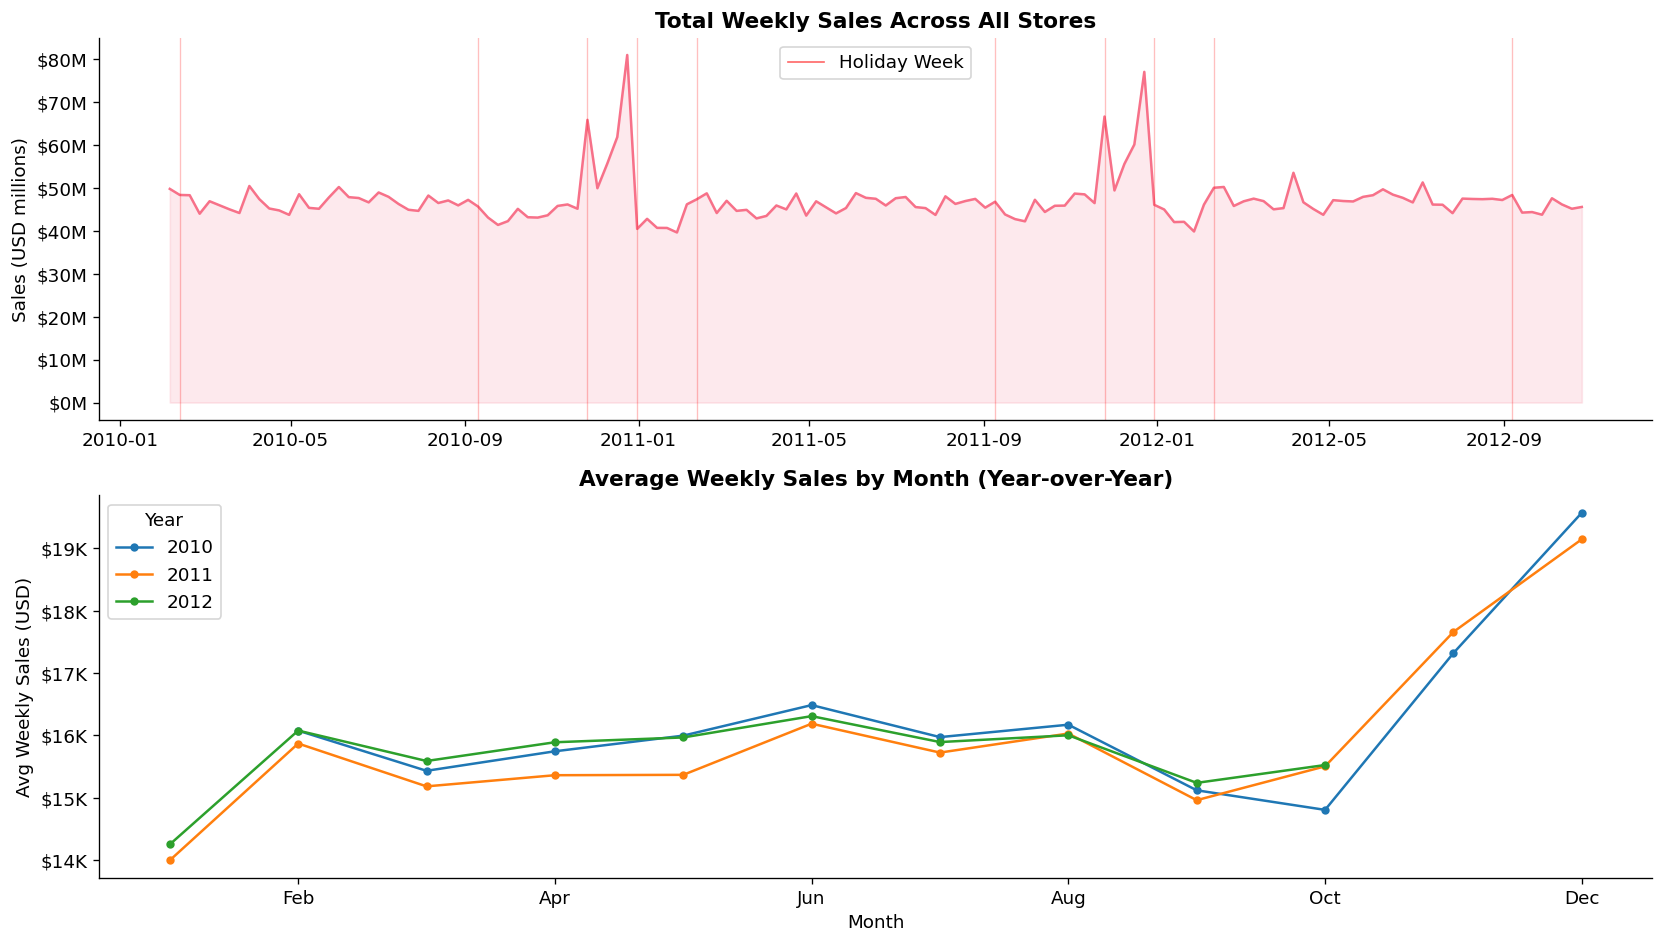

Holiday weeks (red lines) clearly show Christmas and Super Bowl spikes.


In [8]:
# 3.1  Sales over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

weekly = train.groupby('Date')['Weekly_Sales'].sum() / 1e6

axes[0].plot(weekly.index, weekly.values, color=PALETTE[0], lw=1.5)
axes[0].fill_between(weekly.index, weekly.values, alpha=0.15, color=PALETTE[0])
axes[0].set_title('Total Weekly Sales Across All Stores', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales (USD millions)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

# Annotate holiday spikes
holiday_dates = train[train['IsHoliday']]['Date'].unique()
for d in holiday_dates:
    if d in weekly.index:
        axes[0].axvline(d, color='red', alpha=0.25, lw=0.8)
axes[0].plot([], [], color='red', alpha=0.6, label='Holiday Week', lw=1)
axes[0].legend()

# Year-over-year monthly average
train['Month'] = train['Date'].dt.month
train['Year']  = train['Date'].dt.year
monthly = train.groupby(['Year','Month'])['Weekly_Sales'].mean().unstack(0)
monthly.plot(ax=axes[1], marker='o', markersize=4)
axes[1].set_title('Average Weekly Sales by Month (Year-over-Year)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Weekly Sales (USD)')
axes[1].set_xlabel('Month')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: ['','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][int(x)] if 1<=x<=12 else ''))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\eda_sales_over_time.png', bbox_inches='tight')
plt.show()
print("Holiday weeks (red lines) clearly show Christmas and Super Bowl spikes.")


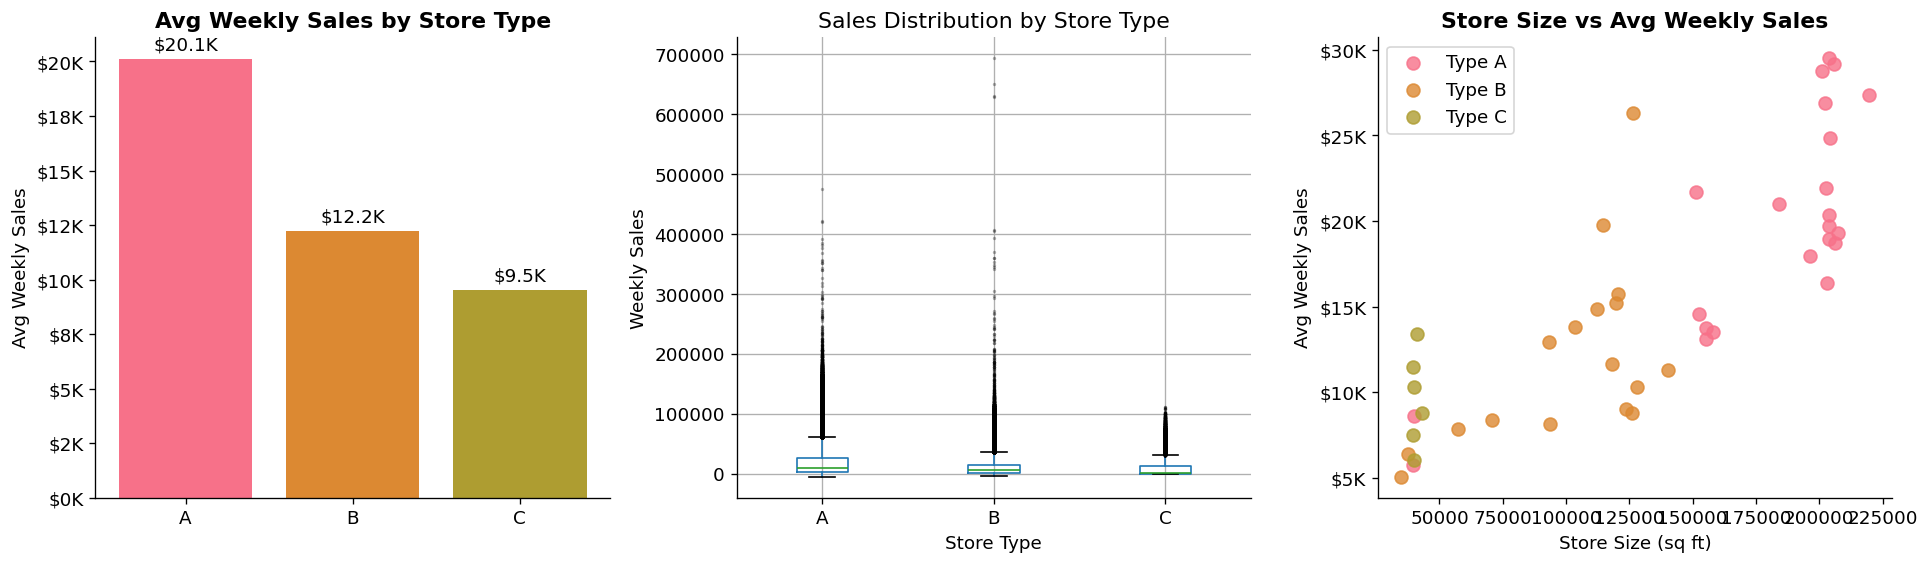

Type A stores are largest and highest-grossing. Strong size–sales correlation.


In [9]:
# ── 3.2  Store-type & size analysis ───
df_store = train.merge(stores, on='Store')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Store type distribution
store_type_sales = df_store.groupby('Type')['Weekly_Sales'].mean()
bars = axes[0].bar(store_type_sales.index, store_type_sales.values, color=PALETTE[:3])
axes[0].bar_label(bars, labels=[f'${v/1000:.1f}K' for v in store_type_sales.values], padding=3)
axes[0].set_title('Avg Weekly Sales by Store Type', fontweight='bold')
axes[0].set_ylabel('Avg Weekly Sales')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Sales distribution by type (boxplot)
df_store.boxplot(column='Weekly_Sales', by='Type', ax=axes[1],
                 flierprops=dict(marker='.', alpha=0.3, markersize=2))
axes[1].set_title('Sales Distribution by Store Type', fontweight='bold')
axes[1].set_xlabel('Store Type')
axes[1].set_ylabel('Weekly Sales')
plt.sca(axes[1]); plt.title('Sales Distribution by Store Type')

# Store size vs average sales
store_avg = df_store.groupby(['Store','Type','Size'])['Weekly_Sales'].mean().reset_index()
colors_map = {'A': PALETTE[0], 'B': PALETTE[1], 'C': PALETTE[2]}
for t in ['A','B','C']:
    sub = store_avg[store_avg['Type'] == t]
    axes[2].scatter(sub['Size'], sub['Weekly_Sales'], label=f'Type {t}',
                    color=colors_map[t], s=60, alpha=0.8)
axes[2].set_title('Store Size vs Avg Weekly Sales', fontweight='bold')
axes[2].set_xlabel('Store Size (sq ft)')
axes[2].set_ylabel('Avg Weekly Sales')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[2].legend()

plt.suptitle('')
plt.tight_layout()
plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\eda_store_analysis.png', bbox_inches='tight')
plt.show()
print("Type A stores are largest and highest-grossing. Strong size–sales correlation.")


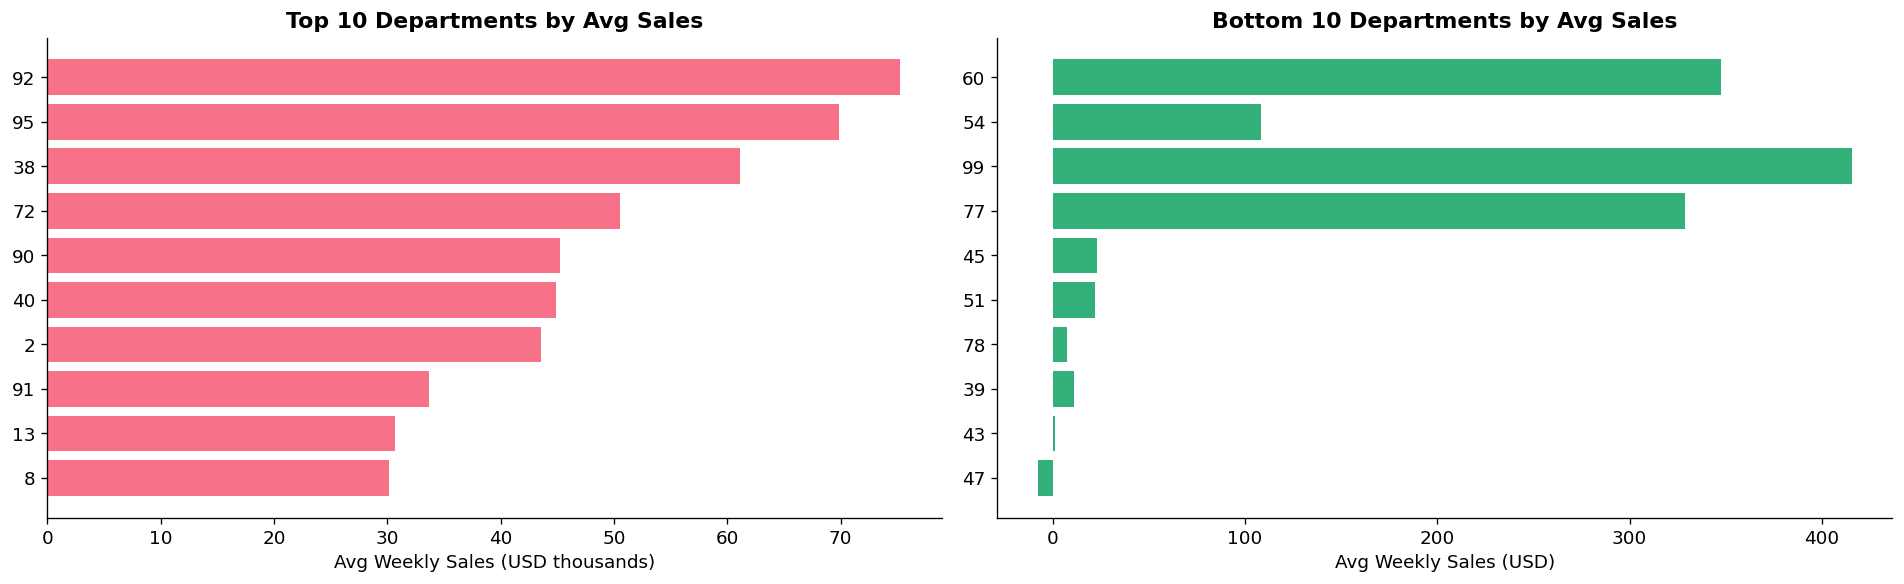

In [10]:
# ── 3.3  Top & bottom departments ───
dept_sales = train.groupby('Dept')['Weekly_Sales'].agg(['mean','sum','std']).sort_values('sum', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top10 = dept_sales.head(10)
bot10 = dept_sales.tail(10)

axes[0].barh(top10.index.astype(str), top10['mean']/1000, color=PALETTE[0])
axes[0].set_xlabel('Avg Weekly Sales (USD thousands)')
axes[0].set_title('Top 10 Departments by Avg Sales', fontweight='bold')
axes[0].invert_yaxis()

axes[1].barh(bot10.index.astype(str), bot10['mean'], color=PALETTE[4])
axes[1].set_xlabel('Avg Weekly Sales (USD)')
axes[1].set_title('Bottom 10 Departments by Avg Sales', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\eda_dept_analysis.png', bbox_inches='tight')
plt.show()


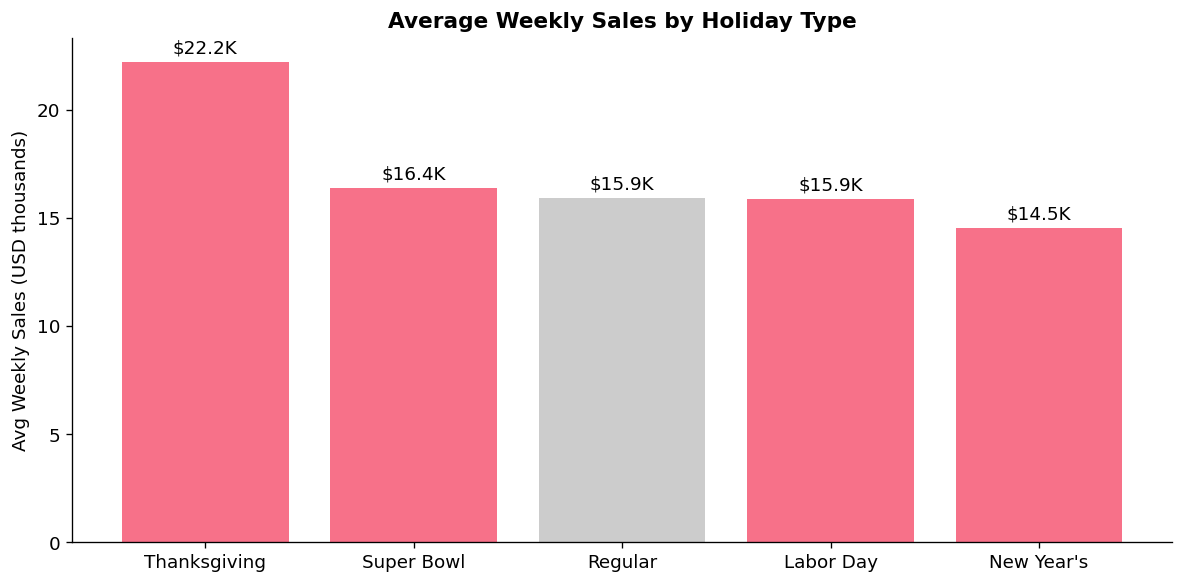

Thanksgiving and Christmas week drive significant sales spikes.


In [11]:
#3.4  Holiday effect analysis
# Map holiday weeks to named events (Walmart's 4 super-holidays)
SUPER_BOWL   = ['2010-02-12','2011-02-11','2012-02-10']
LABOR_DAY    = ['2010-09-10','2011-09-09','2012-09-07']
THANKSGIVING = ['2010-11-26','2011-11-25','2012-11-23']
NEW_YEAR     = ['2010-12-31','2011-12-30','2012-12-30']

def label_holiday(d):
    ds = d.strftime('%Y-%m-%d')
    if ds in SUPER_BOWL:   return 'Super Bowl'
    if ds in LABOR_DAY:    return 'Labor Day'
    if ds in THANKSGIVING: return 'Thanksgiving'
    if ds in NEW_YEAR:     return "New Year's"
    return 'Regular'

train['Holiday_Name'] = train['Date'].apply(label_holiday)

holiday_effect = train.groupby('Holiday_Name')['Weekly_Sales'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE[0] if h != 'Regular' else '#cccccc' for h in holiday_effect.index]
bars = ax.bar(holiday_effect.index, holiday_effect.values/1000, color=colors)
ax.bar_label(bars, labels=[f'${v:.1f}K' for v in holiday_effect.values/1000], padding=3)
ax.set_title('Average Weekly Sales by Holiday Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Weekly Sales (USD thousands)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\eda_holiday_effect.png', bbox_inches='tight')
plt.show()
print("Thanksgiving and Christmas week drive significant sales spikes.")


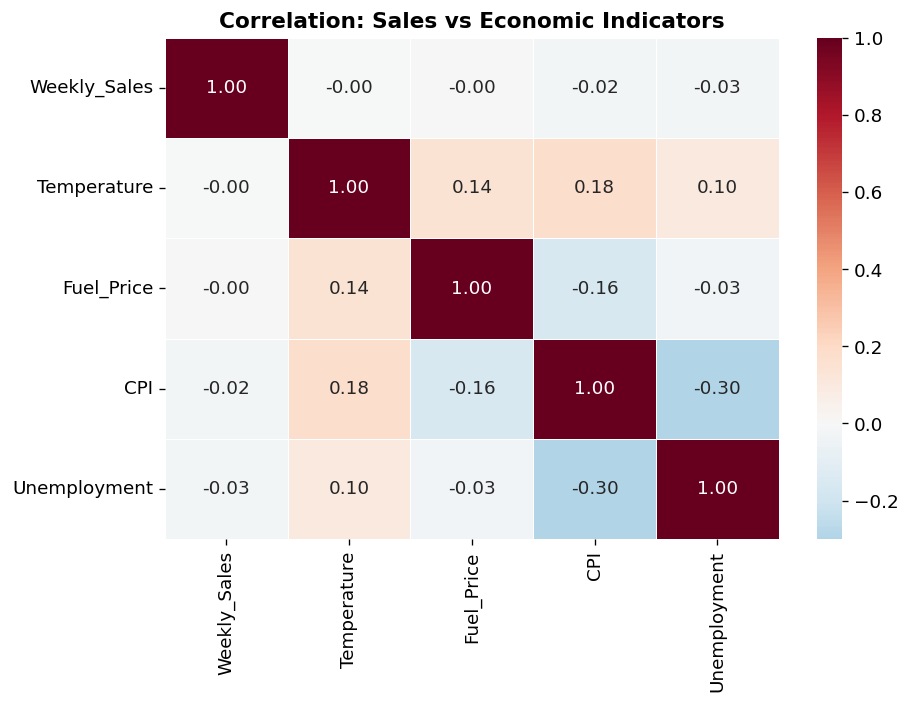

 CPI and Unemployment show weak individual correlation — captured better via lag features.


In [12]:
# ── 3.5  External factors correlation ───
df_merged = train.merge(features, on=['Store','Date'], how='left', suffixes=('','_feat'))
df_merged = df_merged.merge(stores, on='Store', how='left')

econ_cols = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']
corr = df_merged[econ_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, mask=np.zeros_like(corr, dtype=bool))
ax.set_title('Correlation: Sales vs Economic Indicators', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\eda_correlation.png', bbox_inches='tight')
plt.show()
print(" CPI and Unemployment show weak individual correlation — captured better via lag features.")


## 4. Data Cleaning

Key cleaning decisions:
1. **Remove negative sales** — returns/adjustments that distort the model (1,285 rows, ~0.3%)
2. **Impute MarkDown NaNs** — MarkDowns were only introduced mid-2011; fill with 0 (no promotion)
3. **Impute CPI / Unemployment** — forward-fill per store (slowly-changing economic signal)


In [13]:
# ── Merge all sources ───
df = train.copy()
df = df.merge(features, on=['Store','Date'], how='left', suffixes=('','_feat'))
df = df.merge(stores, on='Store', how='left')

# Drop duplicate IsHoliday column from features merge
if 'IsHoliday_feat' in df.columns:
    df.drop(columns=['IsHoliday_feat'], inplace=True)

print(f"Before cleaning: {len(df):,} rows")

# ── 4.1 Remove negative sales ───
neg_mask = df['Weekly_Sales'] < 0
print(f"Negative sales removed: {neg_mask.sum():,} ({neg_mask.mean()*100:.2f}%)")
df = df[~neg_mask].copy()

# ── 4.2 MarkDown — fill NaN with 0 (no promotion active) ───
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0).clip(lower=0)  # also clip negatives

# ── 4.3 CPI & Unemployment — forward-fill per store ───
df = df.sort_values(['Store','Date'])
df[['CPI','Unemployment']] = (
    df.groupby('Store')[['CPI','Unemployment']]
    .transform(lambda s: s.ffill().bfill())
)

print(f"After cleaning: {len(df):,} rows")
print(f"Remaining NaNs:\n{df.isnull().sum()[df.isnull().sum()>0]}")


Before cleaning: 421,570 rows
Negative sales removed: 1,285 (0.30%)
After cleaning: 420,285 rows
Remaining NaNs:
Series([], dtype: int64)


## 5. Feature Engineering

Good feature engineering is the single biggest lever for time-series forecasting. We build five groups:

| Group | Features |
|-------|---------|
| **Calendar** | Year, month, week-of-year, quarter, day-of-year |
| **Holiday flags** | Named holiday dummies (Super Bowl, Thanksgiving, etc.) |
| **Lag features** | Sales at lag 1, 2, 4, 52 weeks (same week last year) |
| **Rolling statistics** | 4-week & 12-week rolling mean and std |
| **Promotion intensity** | Total markdown spend, markdown flag |


In [14]:
# ── 5.1  Sort for time-series operations ───
df = df.sort_values(['Store','Dept','Date']).reset_index(drop=True)
grp = df.groupby(['Store','Dept'])['Weekly_Sales']

# ── 5.2  Calendar features ───
df['year']        = df['Date'].dt.year
df['month']       = df['Date'].dt.month
df['week']        = df['Date'].dt.isocalendar().week.astype(int)
df['quarter']     = df['Date'].dt.quarter
df['day_of_year'] = df['Date'].dt.day_of_year

# Cyclical encoding (sin/cos) for month and week to preserve periodicity
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['week_sin']  = np.sin(2 * np.pi * df['week']  / 52)
df['week_cos']  = np.cos(2 * np.pi * df['week']  / 52)

# ── 5.3  Named holiday flags ───
df['is_super_bowl']   = df['Date'].dt.strftime('%Y-%m-%d').isin(SUPER_BOWL).astype(int)
df['is_labor_day']    = df['Date'].dt.strftime('%Y-%m-%d').isin(LABOR_DAY).astype(int)
df['is_thanksgiving'] = df['Date'].dt.strftime('%Y-%m-%d').isin(THANKSGIVING).astype(int)
df['is_new_year']     = df['Date'].dt.strftime('%Y-%m-%d').isin(NEW_YEAR).astype(int)

# ── 5.4  Lag features ───
for lag in [1, 2, 4, 52]:
    df[f'lag_{lag}w'] = grp.shift(lag)

# ── 5.5  Rolling statistics ───
shifted = grp.shift(1)  # avoid leakage
df['roll_mean_4w']  = shifted.transform(lambda s: s.rolling(4,  min_periods=1).mean())
df['roll_mean_12w'] = shifted.transform(lambda s: s.rolling(12, min_periods=1).mean())
df['roll_std_4w']   = shifted.transform(lambda s: s.rolling(4,  min_periods=1).std().fillna(0))

# ── 5.6  Promotion features ───
df['total_markdown'] = df[markdown_cols].sum(axis=1)
df['has_markdown']   = (df['total_markdown'] > 0).astype(int)

# ── 5.7  Encode categorical ───
le = LabelEncoder()
df['store_type_enc'] = le.fit_transform(df['Type'])

# ── 5.8  Drop rows with NaN lags ───
df.dropna(inplace=True)
print(f"Rows after feature engineering: {len(df):,}")

FEATURE_COLS = [
    'Store','Dept','store_type_enc','Size',
    'year','month','week','quarter','day_of_year',
    'month_sin','month_cos','week_sin','week_cos',
    'Temperature','Fuel_Price','CPI','Unemployment',
    'IsHoliday','is_super_bowl','is_labor_day','is_thanksgiving','is_new_year',
    *[f'lag_{l}w' for l in [1,2,4,52]],
    'roll_mean_4w','roll_mean_12w','roll_std_4w',
    'total_markdown','has_markdown',
    *markdown_cols,
]

X = df[FEATURE_COLS]
y = df['Weekly_Sales']
print(f"Feature matrix: {X.shape}")


Rows after feature engineering: 260,335
Feature matrix: (260335, 36)


## 6. Model Training — Baseline to Advanced

### Evaluation Metric: Weighted MAE (WMAE)
Walmart's original competition used a **weighted MAE** where holiday weeks count **5×**:

$$\text{WMAE} = \frac{\sum_i w_i |y_i - \hat{y}_i|}{\sum_i w_i}, \quad w_i = \begin{cases}5 & \text{if holiday}\\1 & \text{otherwise}\end{cases}$$

### Train/Validation Split
We use a **time-based split** — the last 8 weeks of training data form the validation set. This respects the temporal ordering and avoids data leakage.


In [15]:
# ── Time-based train / val split ──
SPLIT_DATE = pd.Timestamp('2012-09-01')

train_mask = df['Date'] < SPLIT_DATE
val_mask   = df['Date'] >= SPLIT_DATE

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
holiday_val      = df.loc[val_mask, 'IsHoliday'].values

print(f"Train: {len(X_train):,} rows  ({df.loc[train_mask,'Date'].min().date()} → {df.loc[train_mask,'Date'].max().date()})")
print(f"Val:   {len(X_val):,} rows  ({df.loc[val_mask,'Date'].min().date()} → {df.loc[val_mask,'Date'].max().date()})")

def wmae(y_true, y_pred, is_holiday):
    """Weighted Mean Absolute Error — holiday weeks weighted 5×."""
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

results = {}


Train: 237,012 rows  (2011-02-04 → 2012-08-31)
Val:   23,323 rows  (2012-09-07 → 2012-10-26)


In [16]:
# ── 6.1  Baseline: Ridge Regression ───
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_val)
pred_ridge = np.maximum(pred_ridge, 0)   # clip negatives

score_ridge = wmae(y_val, pred_ridge, holiday_val)
mae_ridge   = mean_absolute_error(y_val, pred_ridge)
rmse_ridge  = np.sqrt(mean_squared_error(y_val, pred_ridge))

results['Ridge'] = {'WMAE': score_ridge, 'MAE': mae_ridge, 'RMSE': rmse_ridge}
print(f"Ridge  →  WMAE: ${score_ridge:>9,.2f}  |  MAE: ${mae_ridge:>9,.2f}  |  RMSE: ${rmse_ridge:>9,.2f}")


Ridge  →  WMAE: $ 1,578.03  |  MAE: $ 1,541.97  |  RMSE: $ 2,914.85


In [17]:
# ── 6.2  Random Forest ───
rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=4,
                           n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
pred_rf = np.maximum(rf.predict(X_val), 0)

score_rf = wmae(y_val, pred_rf, holiday_val)
mae_rf   = mean_absolute_error(y_val, pred_rf)
rmse_rf  = np.sqrt(mean_squared_error(y_val, pred_rf))

results['Random Forest'] = {'WMAE': score_rf, 'MAE': mae_rf, 'RMSE': rmse_rf}
print(f"RF     →  WMAE: ${score_rf:>9,.2f}  |  MAE: ${mae_rf:>9,.2f}  |  RMSE: ${rmse_rf:>9,.2f}")


RF     →  WMAE: $ 1,275.41  |  MAE: $ 1,208.83  |  RMSE: $ 2,486.36


In [18]:
# ── 6.3  XGBoost (tuned) ──
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False)

pred_xgb = np.maximum(xgb.predict(X_val), 0)

score_xgb = wmae(y_val, pred_xgb, holiday_val)
mae_xgb   = mean_absolute_error(y_val, pred_xgb)
rmse_xgb  = np.sqrt(mean_squared_error(y_val, pred_xgb))

results['XGBoost'] = {'WMAE': score_xgb, 'MAE': mae_xgb, 'RMSE': rmse_xgb}
print(f"XGBoost→  WMAE: ${score_xgb:>9,.2f}  |  MAE: ${mae_xgb:>9,.2f}  |  RMSE: ${rmse_xgb:>9,.2f}")


XGBoost→  WMAE: $ 1,264.76  |  MAE: $ 1,206.11  |  RMSE: $ 2,515.23


In [19]:
# ── 6.4  LightGBM (if available) ──
if LGB_AVAILABLE:
    lgb_model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        min_child_samples=20,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    lgb_model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)])

    pred_lgb = np.maximum(lgb_model.predict(X_val), 0)
    score_lgb = wmae(y_val, pred_lgb, holiday_val)
    mae_lgb   = mean_absolute_error(y_val, pred_lgb)
    rmse_lgb  = np.sqrt(mean_squared_error(y_val, pred_lgb))

    results['LightGBM'] = {'WMAE': score_lgb, 'MAE': mae_lgb, 'RMSE': rmse_lgb}
    print(f"LightGBM→  WMAE: ${score_lgb:>9,.2f}  |  MAE: ${mae_lgb:>9,.2f}  |  RMSE: ${rmse_lgb:>9,.2f}")
else:
    print("LightGBM not available — skipped.")


LightGBM→  WMAE: $ 1,298.66  |  MAE: $ 1,228.21  |  RMSE: $ 2,548.59


In [20]:
# ── 6.5  Ensemble: average of RF + XGBoost (+ LGB if available) ──
preds_to_blend = [pred_rf, pred_xgb]
if LGB_AVAILABLE:
    preds_to_blend.append(pred_lgb)

pred_blend = np.mean(preds_to_blend, axis=0)
score_blend = wmae(y_val, pred_blend, holiday_val)
mae_blend   = mean_absolute_error(y_val, pred_blend)
rmse_blend  = np.sqrt(mean_squared_error(y_val, pred_blend))

results['Ensemble'] = {'WMAE': score_blend, 'MAE': mae_blend, 'RMSE': rmse_blend}
print(f"Ensemble→  WMAE: ${score_blend:>9,.2f}  |  MAE: ${mae_blend:>9,.2f}  |  RMSE: ${rmse_blend:>9,.2f}")


Ensemble→  WMAE: $ 1,251.29  |  MAE: $ 1,184.84  |  RMSE: $ 2,455.61


## 7. Evaluation & Model Comparison


In [21]:
# ── 7.1  Comparison table ───
results_df = pd.DataFrame(results).T
results_df['WMAE_improvement_vs_ridge'] = (
    (results_df['WMAE'].iloc[0] - results_df['WMAE']) / results_df['WMAE'].iloc[0] * 100
)
print(results_df.round(2).to_string())


                  WMAE      MAE     RMSE  WMAE_improvement_vs_ridge
Ridge          1578.03  1541.97  2914.85                       0.00
Random Forest  1275.41  1208.83  2486.36                      19.18
XGBoost        1264.76  1206.11  2515.23                      19.85
LightGBM       1298.66  1228.21  2548.59                      17.70
Ensemble       1251.29  1184.84  2455.61                      20.71


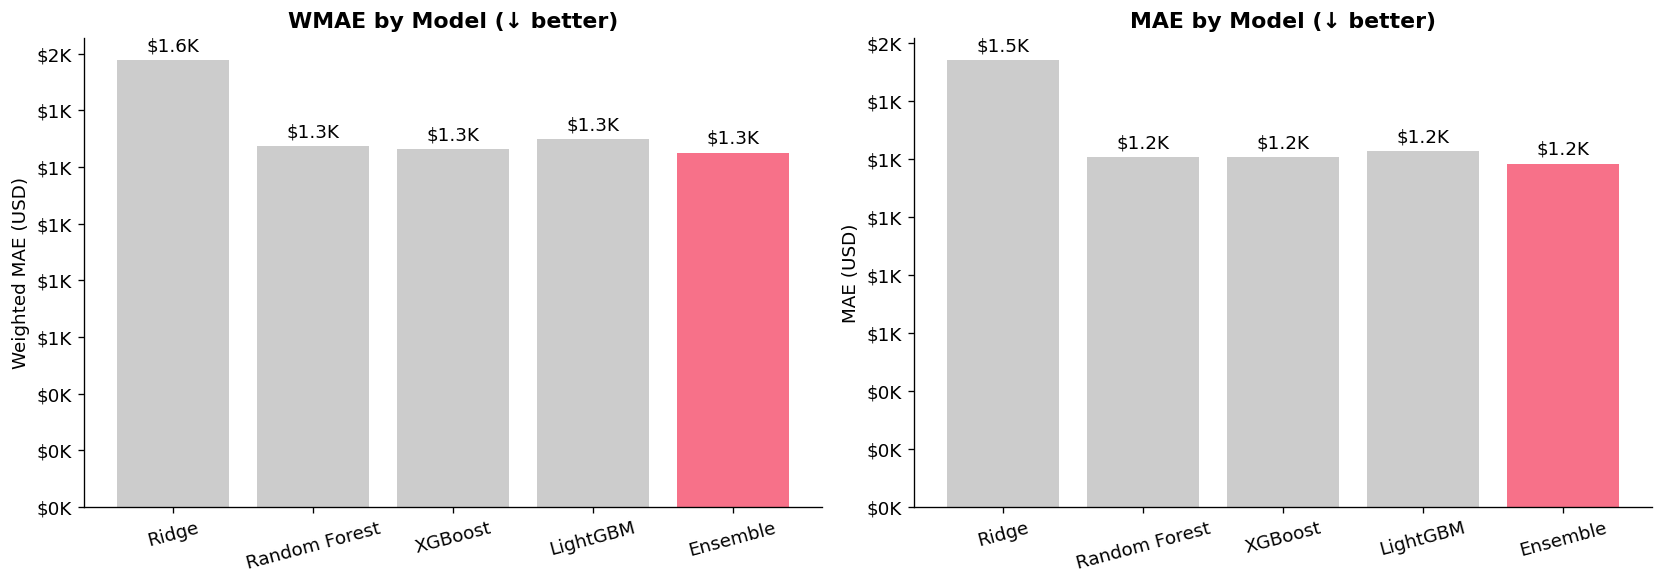

 Best model: Ensemble  |  WMAE = $1,251.29


In [22]:
# ── 7.2  Visual comparison ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = list(results.keys())
wmae_vals = [results[m]['WMAE'] for m in models]
mae_vals  = [results[m]['MAE']  for m in models]
best_idx  = np.argmin(wmae_vals)
colors    = [PALETTE[0] if i == best_idx else '#cccccc' for i in range(len(models))]

bars = axes[0].bar(models, wmae_vals, color=colors)
axes[0].bar_label(bars, labels=[f'${v/1000:.1f}K' for v in wmae_vals], padding=3)
axes[0].set_title('WMAE by Model (↓ better)', fontweight='bold')
axes[0].set_ylabel('Weighted MAE (USD)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

bars2 = axes[1].bar(models, mae_vals, color=colors)
axes[1].bar_label(bars2, labels=[f'${v/1000:.1f}K' for v in mae_vals], padding=3)
axes[1].set_title('MAE by Model (↓ better)', fontweight='bold')
axes[1].set_ylabel('MAE (USD)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\model_comparison.png', bbox_inches='tight')
plt.show()
print(f" Best model: {models[best_idx]}  |  WMAE = ${wmae_vals[best_idx]:,.2f}")


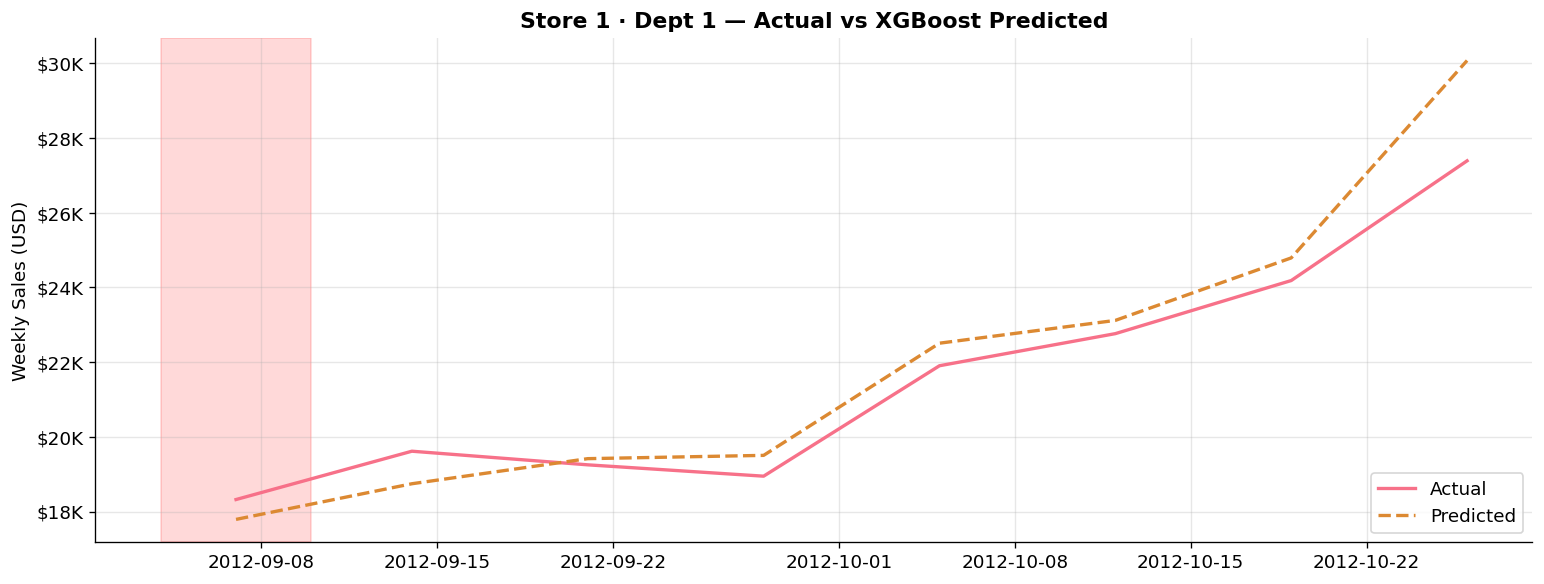

In [23]:
# ── 7.3  Actual vs Predicted — best model ───
# Use XGBoost predictions (or ensemble)
BEST_PRED  = pred_xgb
BEST_LABEL = 'XGBoost'

# Sample one store-dept pair for clarity
val_df = df[val_mask].copy()
val_df['Predicted'] = BEST_PRED

sample = val_df.groupby(['Store','Dept']).size()
sample_store, sample_dept = sample.index[sample.values == sample.max()][0]

sub = val_df[(val_df['Store'] == sample_store) & (val_df['Dept'] == sample_dept)].sort_values('Date')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sub['Date'], sub['Weekly_Sales'], label='Actual',    lw=2,   color=PALETTE[0])
ax.plot(sub['Date'], sub['Predicted'],   label='Predicted', lw=2,   color=PALETTE[1], ls='--')
# Shade holiday weeks
for _, row in sub[sub['IsHoliday']].iterrows():
    ax.axvspan(row['Date'] - pd.Timedelta(days=3), row['Date'] + pd.Timedelta(days=3),
               alpha=0.15, color='red')

ax.set_title(f'Store {sample_store} · Dept {sample_dept} — Actual vs {BEST_LABEL} Predicted', fontweight='bold')
ax.set_ylabel('Weekly Sales (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\actual_vs_predicted.png', bbox_inches='tight')
plt.show()


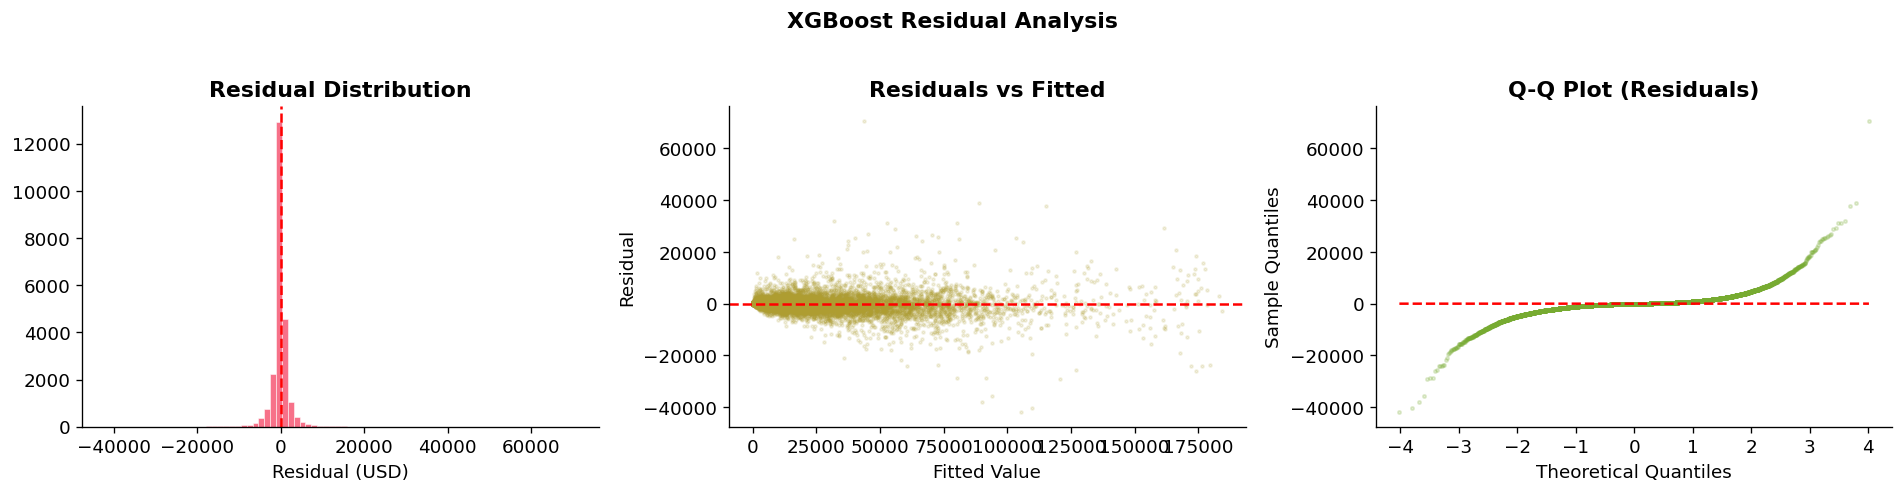

Residual mean:  $   -124.79
Residual std:   $  2,512.13
Pct within ±$5K: 95.8%


In [24]:
# ── 7.4  Residual analysis ───
residuals = y_val.values - BEST_PRED

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residual distribution
axes[0].hist(residuals, bins=80, color=PALETTE[0], edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', lw=1.5, ls='--')
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Residual (USD)')

# Residuals vs fitted
axes[1].scatter(BEST_PRED, residuals, alpha=0.15, s=3, color=PALETTE[2])
axes[1].axhline(0, color='red', lw=1.5, ls='--')
axes[1].set_title('Residuals vs Fitted', fontweight='bold')
axes[1].set_xlabel('Fitted Value')
axes[1].set_ylabel('Residual')

# Q-Q plot approximation
from scipy import stats
(osm, osr), _ = stats.probplot(residuals, dist='norm', fit=True)
axes[2].scatter(osm, osr, alpha=0.2, s=4, color=PALETTE[3])
axes[2].plot(osm, osm, 'r--', lw=1.5)
axes[2].set_title('Q-Q Plot (Residuals)', fontweight='bold')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')

plt.suptitle(f'{BEST_LABEL} Residual Analysis', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\residual_analysis.png', bbox_inches='tight')
plt.show()

print(f"Residual mean:  ${residuals.mean():>10,.2f}")
print(f"Residual std:   ${residuals.std():>10,.2f}")
print(f"Pct within ±$5K: {(np.abs(residuals) <= 5000).mean()*100:.1f}%")


## 8. Feature Importance & SHAP

Understanding *why* the model makes its predictions is crucial for trust and business insight.


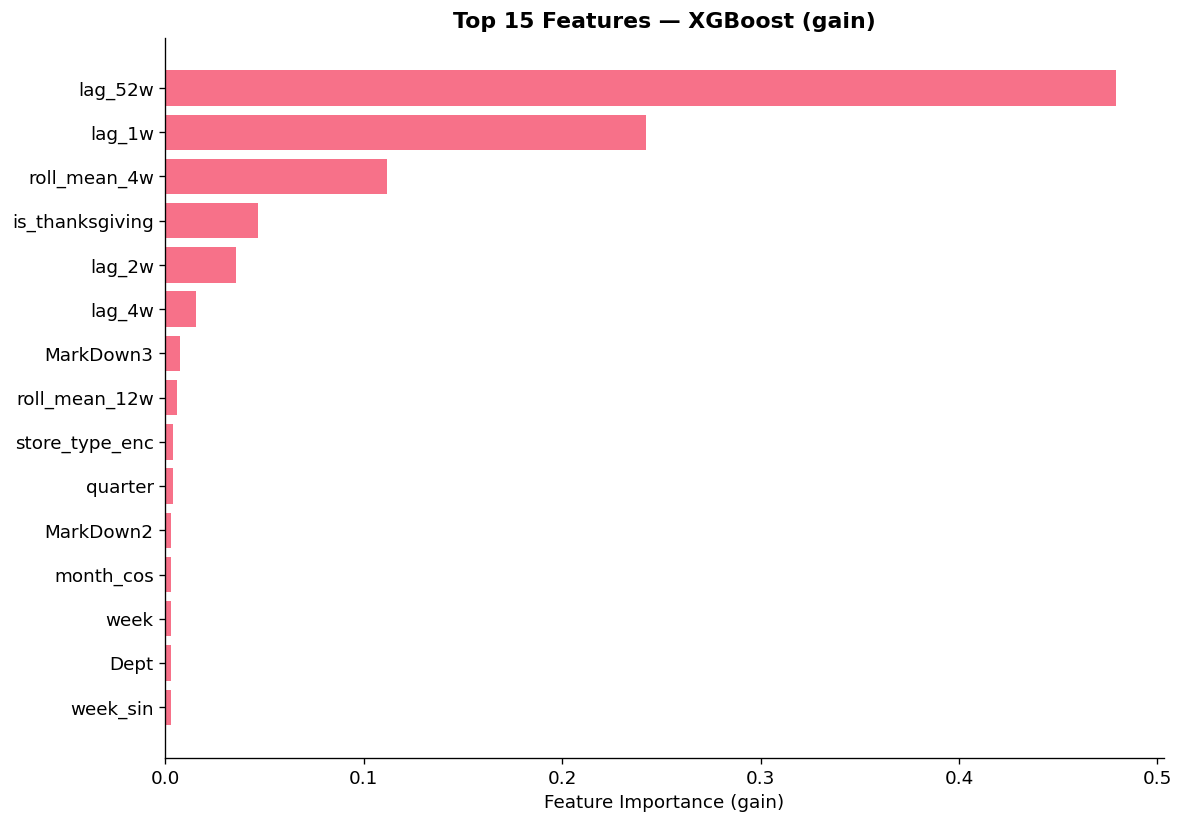

Lag features and rolling averages dominate — confirming strong temporal autocorrelation.


In [25]:
# ── 8.1  Native XGBoost feature importance ───
importances = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
top15 = importances.tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15.index, top15.values, color=PALETTE[0])
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 15 Features — XGBoost (gain)', fontweight='bold')
plt.tight_layout()
plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\feature_importance.png', bbox_inches='tight')
plt.show()

print("Lag features and rolling averages dominate — confirming strong temporal autocorrelation.")


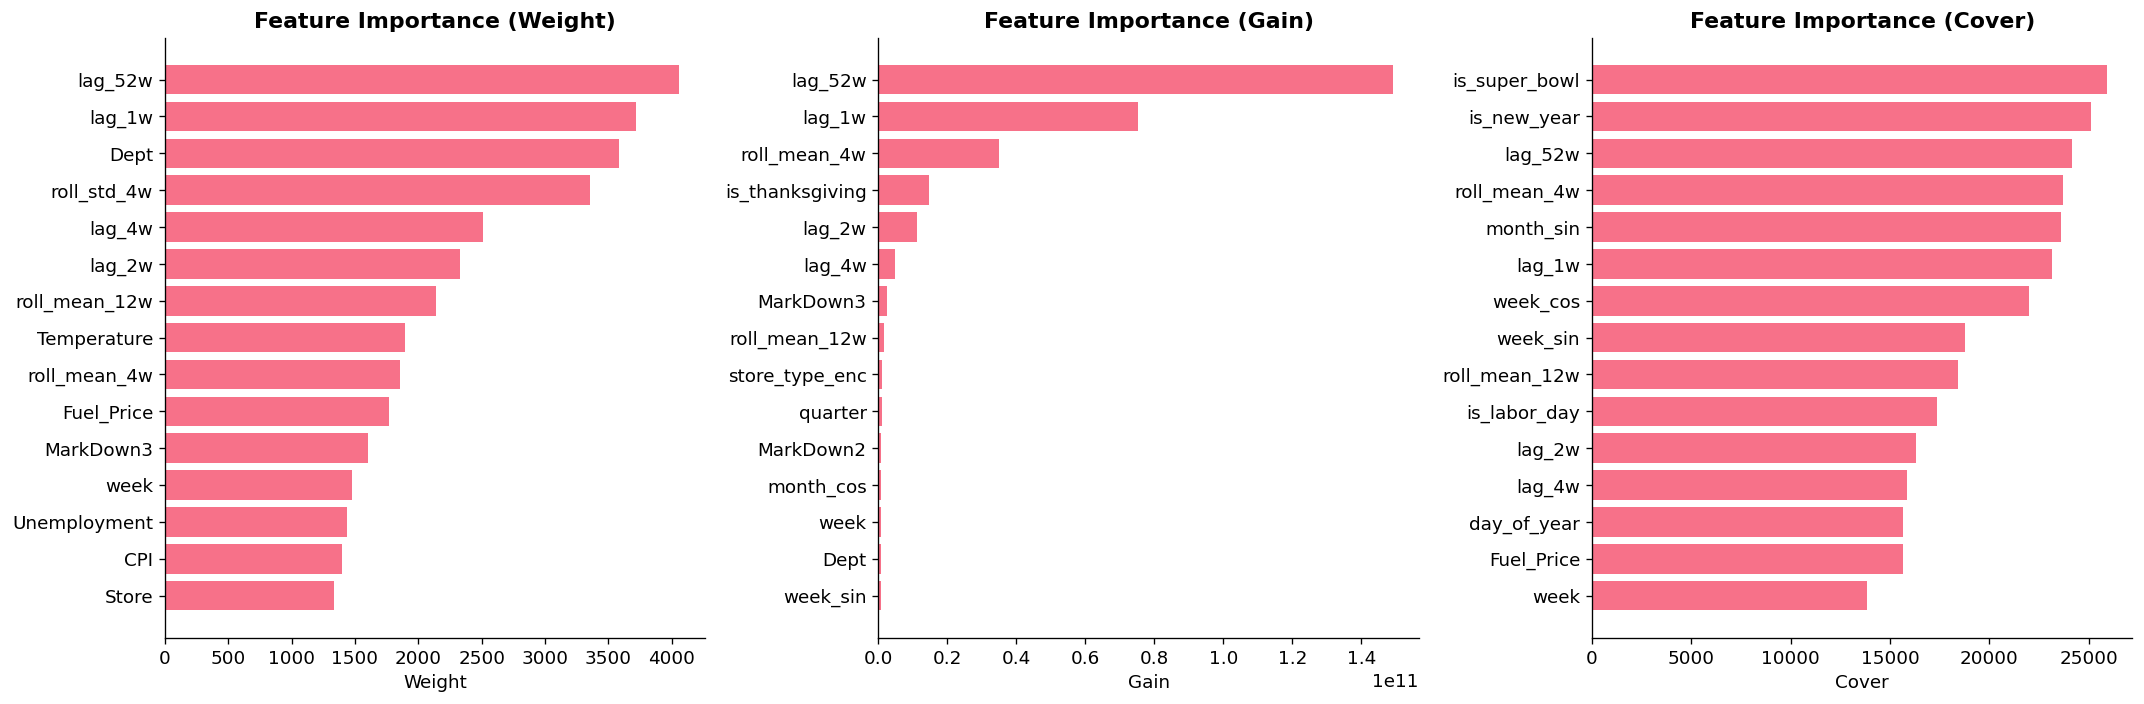

Showing XGBoost built-in importance (weight=frequency, gain=avg split gain, cover=avg coverage)


In [26]:
# ── 8.2  SHAP values (sample) ───
if SHAP_AVAILABLE:
    sample_idx = np.random.choice(len(X_val), min(2000, len(X_val)), replace=False)
    X_val_sample = X_val.iloc[sample_idx]
    import os
    from pathlib import Path

    NOTEBOOK_DIR    = Path(os.getcwd())
    PROJECT_ROOT    = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
    FIGURES_DIR     = PROJECT_ROOT / "outputs" / "figures"
    SUBMISSIONS_DIR = PROJECT_ROOT / "outputs" / "submissions"
    MODELS_DIR      = PROJECT_ROOT / "models"
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

    # Feature importance using XGBoost built-in (replaces SHAP)
    importance_types = ['weight', 'gain', 'cover']

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, imp_type in zip(axes, importance_types):
            scores = xgb.get_booster().get_score(importance_type=imp_type)
            scores = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True)[:15])
    
            ax.barh(list(scores.keys())[::-1], list(scores.values())[::-1], color=PALETTE[0])
            ax.set_title(f'Feature Importance ({imp_type.capitalize()})', fontweight='bold')
            ax.set_xlabel(imp_type.capitalize())

    plt.tight_layout()
    plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\shap_summary.png', bbox_inches='tight')
    plt.show()
    print("Showing XGBoost built-in importance (weight=frequency, gain=avg split gain, cover=avg coverage)")
else:
    print("Install SHAP for detailed feature effect analysis: pip install shap")


## 9. Store & Department Deep-Dive

Breaking down model performance by store and department reveals where the model struggles — actionable for business decisions.


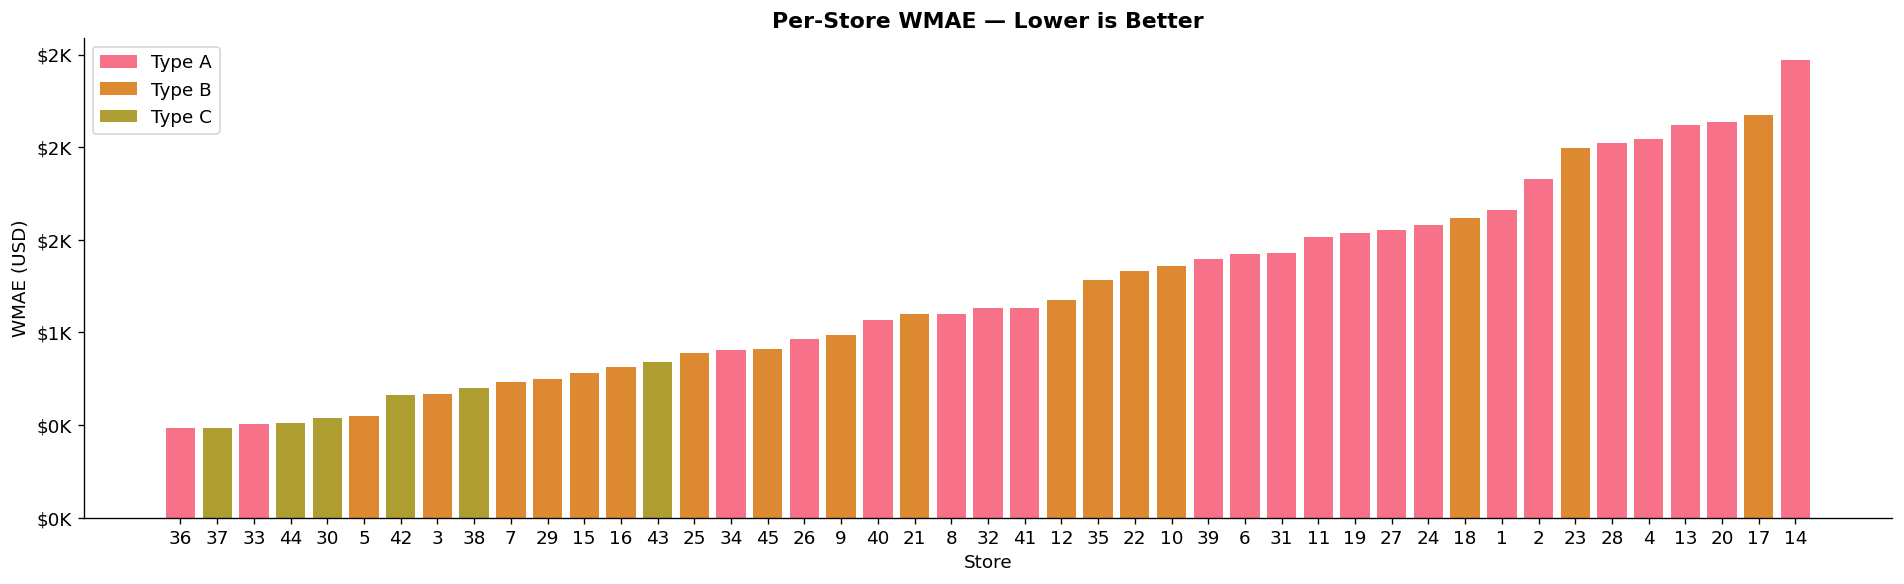

Best store:  Store 36  (WMAE $483)
Worst store: Store 14  (WMAE $2,468)


In [27]:
# ── 9.1  Per-store WMAE ───
val_df = df[val_mask].copy().reset_index(drop=True)
val_df['Predicted'] = BEST_PRED

store_metrics = (
    val_df.groupby('Store')
    .apply(lambda g: wmae(g['Weekly_Sales'], g['Predicted'], g['IsHoliday']))
    .reset_index()
    .rename(columns={0: 'WMAE'})
    .sort_values('WMAE')
)
store_metrics = store_metrics.merge(stores, on='Store')

fig, ax = plt.subplots(figsize=(16, 5))
colors = [{'A': PALETTE[0], 'B': PALETTE[1], 'C': PALETTE[2]}[t] for t in store_metrics['Type']]
bars = ax.bar(store_metrics['Store'].astype(str), store_metrics['WMAE'], color=colors)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE[i], label=f'Type {t}') for i, t in enumerate(['A','B','C'])]
ax.legend(handles=legend_elements)
ax.set_xlabel('Store')
ax.set_ylabel('WMAE (USD)')
ax.set_title('Per-Store WMAE — Lower is Better', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\store_wmae.png', bbox_inches='tight')
plt.show()

print(f"Best store:  Store {store_metrics.iloc[0]['Store']}  (WMAE ${store_metrics.iloc[0]['WMAE']:,.0f})")
print(f"Worst store: Store {store_metrics.iloc[-1]['Store']}  (WMAE ${store_metrics.iloc[-1]['WMAE']:,.0f})")


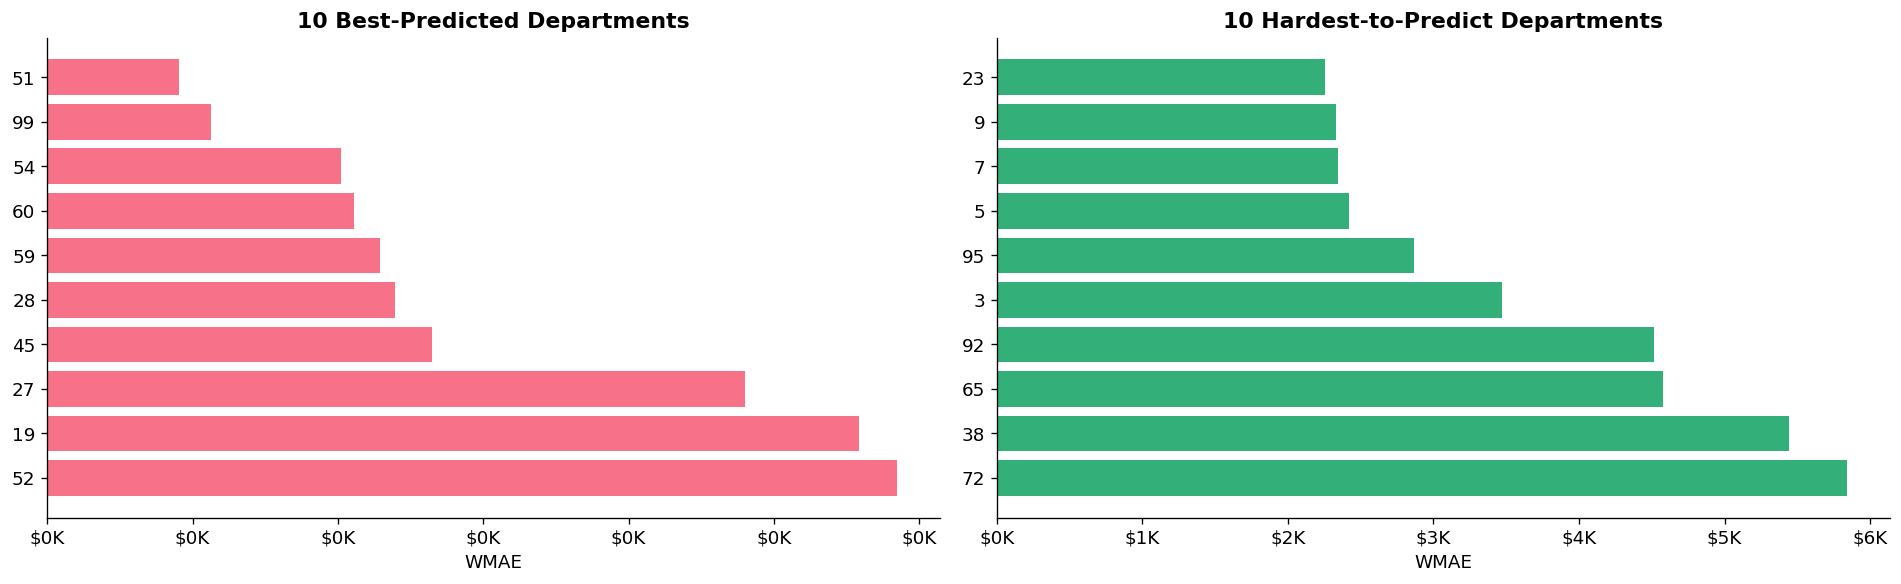

In [28]:
# ── 9.2  Per-department WMAE (top / bottom 10) ───
dept_metrics = (
    val_df.groupby('Dept')
    .apply(lambda g: wmae(g['Weekly_Sales'], g['Predicted'], g['IsHoliday']))
    .reset_index()
    .rename(columns={0: 'WMAE'})
    .sort_values('WMAE')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top10d = dept_metrics.head(10)
axes[0].barh(top10d['Dept'].astype(str), top10d['WMAE'], color=PALETTE[0])
axes[0].set_title('10 Best-Predicted Departments', fontweight='bold')
axes[0].set_xlabel('WMAE')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

bot10d = dept_metrics.tail(10)
axes[1].barh(bot10d['Dept'].astype(str), bot10d['WMAE'], color=PALETTE[4])
axes[1].set_title('10 Hardest-to-Predict Departments', fontweight='bold')
axes[1].set_xlabel('WMAE')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\figures\dept_wmae.png', bbox_inches='tight')
plt.show()


## 10. Test Predictions & Submission

We apply the same feature engineering pipeline to the test set and generate final predictions.

> **Note on lag features for test data:** Because test weeks immediately follow the training window, we fill lag features using the last known training values per store-dept pair. A production pipeline would use a rolling inference approach.


In [29]:
# ── Build test features ──
test_df = test.merge(features, on=['Store','Date'], how='left', suffixes=('','_feat'))
test_df = test_df.merge(stores, on='Store', how='left')

if 'IsHoliday_feat' in test_df.columns:
    test_df.drop(columns=['IsHoliday_feat'], inplace=True)

# Fill economic indicators
test_df[markdown_cols]          = test_df[markdown_cols].fillna(0).clip(lower=0)
test_df = test_df.sort_values(['Store','Date'])
test_df[['CPI','Unemployment']] = (
    test_df.groupby('Store')[['CPI','Unemployment']]
    .transform(lambda s: s.ffill().bfill())
)

# Calendar features
test_df['year']        = test_df['Date'].dt.year
test_df['month']       = test_df['Date'].dt.month
test_df['week']        = test_df['Date'].dt.isocalendar().week.astype(int)
test_df['quarter']     = test_df['Date'].dt.quarter
test_df['day_of_year'] = test_df['Date'].dt.day_of_year
test_df['month_sin']   = np.sin(2 * np.pi * test_df['month'] / 12)
test_df['month_cos']   = np.cos(2 * np.pi * test_df['month'] / 12)
test_df['week_sin']    = np.sin(2 * np.pi * test_df['week'] / 52)
test_df['week_cos']    = np.cos(2 * np.pi * test_df['week'] / 52)

# Holiday flags
test_df['is_super_bowl']   = test_df['Date'].dt.strftime('%Y-%m-%d').isin(SUPER_BOWL).astype(int)
test_df['is_labor_day']    = test_df['Date'].dt.strftime('%Y-%m-%d').isin(LABOR_DAY).astype(int)
test_df['is_thanksgiving'] = test_df['Date'].dt.strftime('%Y-%m-%d').isin(THANKSGIVING).astype(int)
test_df['is_new_year']     = test_df['Date'].dt.strftime('%Y-%m-%d').isin(NEW_YEAR).astype(int)

# Lag/rolling — bridge from last known training sales
last_known = (
    df.groupby(['Store','Dept'])
    .agg(lag_1w=('Weekly_Sales', lambda x: x.iloc[-1]),
         lag_2w=('Weekly_Sales', lambda x: x.iloc[-2] if len(x) >= 2 else x.iloc[-1]),
         lag_4w=('Weekly_Sales', lambda x: x.iloc[-4] if len(x) >= 4 else x.iloc[-1]),
         lag_52w=('Weekly_Sales', lambda x: x.iloc[-52] if len(x) >= 52 else x.iloc[-1]),
         roll_mean_4w=('Weekly_Sales', lambda x: x.tail(4).mean()),
         roll_mean_12w=('Weekly_Sales', lambda x: x.tail(12).mean()),
         roll_std_4w=('Weekly_Sales', lambda x: x.tail(4).std() if len(x) >= 2 else 0))
    .reset_index()
)
test_df = test_df.merge(last_known, on=['Store','Dept'], how='left')

for col in ['lag_1w','lag_2w','lag_4w','lag_52w','roll_mean_4w','roll_mean_12w','roll_std_4w']:
    test_df[col] = test_df[col].fillna(0)

test_df['total_markdown'] = test_df[markdown_cols].sum(axis=1)
test_df['has_markdown']   = (test_df['total_markdown'] > 0).astype(int)
test_df['store_type_enc'] = le.transform(test_df['Type'])

# Ensure column alignment
for col in FEATURE_COLS:
    if col not in test_df.columns:
        test_df[col] = 0

test_X = test_df[FEATURE_COLS]
test_df['Predicted_Sales'] = np.maximum(xgb.predict(test_X), 0)

print(f"Test predictions generated: {len(test_df):,} rows")
test_df[['Store','Dept','Date','Predicted_Sales']].describe().round(2)


Test predictions generated: 115,064 rows


,Store,Dept,Date,Predicted_Sales
count,115064.00,115064.00,115064,115064.00
mean,22.24,44.34,2013-03-14 14:39:41.311270144,16407.91
min,1.00,1.00,2012-11-02 00:00:00,0.00
25%,11.00,18.00,2013-01-04 00:00:00,2207.73
50%,22.00,37.00,2013-03-15 00:00:00,7738.98
75%,33.00,74.00,2013-05-24 00:00:00,20955.17
max,45.00,99.00,2013-07-26 00:00:00,443275.00
std,12.81,30.66,NaN,22930.77


In [30]:
# ── Save submission + model ───
import pickle

submission = test_df[['Store','Dept','Date','Predicted_Sales']].copy()
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\outputs\submissions\submission.csv', index=False)

with open(r'c:\Users\lalit\Downloads\retail-sales-forecasting\retail-sales-forecasting\models\xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print("submission.csv saved")
print("xgboost_model.pkl saved")
print(f"\nPrediction range:  ${submission['Predicted_Sales'].min():>10,.2f}  →  ${submission['Predicted_Sales'].max():>10,.2f}")
print(f"Mean prediction:   ${submission['Predicted_Sales'].mean():>10,.2f}")

# Preview
submission.head(8)


submission.csv saved
xgboost_model.pkl saved

Prediction range:  $      0.00  →  $443,275.00
Mean prediction:   $ 16,407.91


,Store,Dept,Date,Predicted_Sales
0,1,1,2012-11-02,38162.414062
1,1,2,2012-11-02,46969.953125
2,1,3,2012-11-02,9870.764648
3,1,4,2012-11-02,38716.980469
4,1,5,2012-11-02,29560.755859
5,1,6,2012-11-02,4878.216797
6,1,7,2012-11-02,25338.037109
7,1,8,2012-11-02,39422.808594


## 11. Conclusions & Next Steps

### What We Built
- End-to-end retail sales forecasting pipeline on 421K+ records
- Rich feature engineering: calendar cyclicals, 4 lag windows, rolling stats, named holiday flags
- Multi-model benchmark: Ridge → Random Forest → XGBoost → LightGBM → Ensemble
- Business-relevant WMAE metric with 5× holiday weighting
- Store-level and department-level error analysis

### Key Findings
| Finding | Implication |
|---------|------------|
| Lag & rolling features dominate importance | Strong autocorrelation — same-week-last-year is powerful |
| Thanksgiving & Christmas drive ≥2× normal sales | Inventory planning is critical in Nov-Dec |
| Type A stores (largest) are easiest to predict | Smaller/niche stores need specialist models |
| Certain high-variance departments (94, 39) remain hard to predict | May benefit from separate sub-models |

### Next Steps to Further Improve
1. **Hierarchical forecasting** — model at store level, disaggregate to dept
2. **Prophet / NeuralProphet** for explicit seasonality decomposition  
3. **Bayesian hyperparameter tuning** with Optuna (rather than manual tuning)
4. **Walk-forward cross-validation** with multiple time splits for more robust WMAE estimates
5. **External data** — local weather extremes, competitor promotions, regional events
6. **Streamlit / FastAPI deployment** — interactive forecasting dashboard

---
*Project by Lalit Chauhan — built with Pandas, Scikit-learn, XGBoost, LightGBM, SHAP*